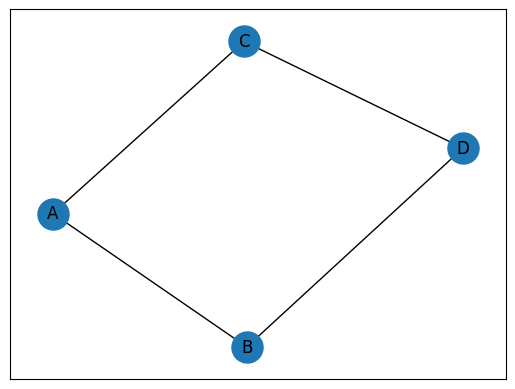

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph() # utworzenie grafu G
G.add_edge('A', 'B', weight=4) # Dodanie do grafu krawędzi z wagami
G.add_edge('B', 'D', weight=2)
G.add_edge('A', 'C', weight=3)
G.add_edge('C', 'D', weight=4)
pos = nx.spring_layout(G) # przydzielnie pozycji dla każdego węzła w G
nx.draw_networkx_nodes(G, pos, node_size = 500) #narysowanie węzłów grafu
nx.draw_networkx_labels(G, pos) #narysowanie etykiet węzłów
nx.draw_networkx_edges(G, pos) #narysowanie krawędzi grafów
plt.show() #wyświetlenie grafu

ZADANIE 2


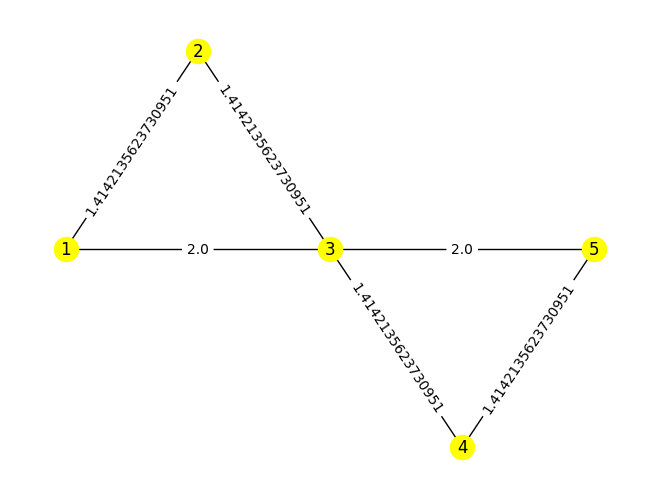

In [1]:
# zadanie 2 Uruchom (i przeanalizuj) następujący program
print("ZADANIE 2")

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.Graph()
VV = [1, 2, 3, 4, 5]
WW = [(1, 2), (2, 3), (3, 4), (4, 5), (1, 3), (3, 5)]
Vx = {1:0, 2:1, 3:2, 4:3, 5:4}
Vy = {1:0, 2:1, 3:0, 4:-1, 5:0}

g = nx.Graph();
gpos = {};
for v in VV:
    g.add_node(v);
    gpos[v] = [Vx[v], Vy[v]]
for v1 in VV:
    for v2 in VV:
        if (v1, v2) in WW:
            label = str(np.sqrt((Vx[v1] - Vx[v2])**2 + (Vy[v1] - Vy[v2])**2))
            g.add_weighted_edges_from([(v1, v2, label)])
nx.draw(g, gpos, with_labels=True, node_color = 'yellow')
labels = nx.get_edge_attributes(g, 'weight')
nx.draw_networkx_edge_labels(g, gpos, edge_labels=labels)

plt.show()

ZADANIE 3


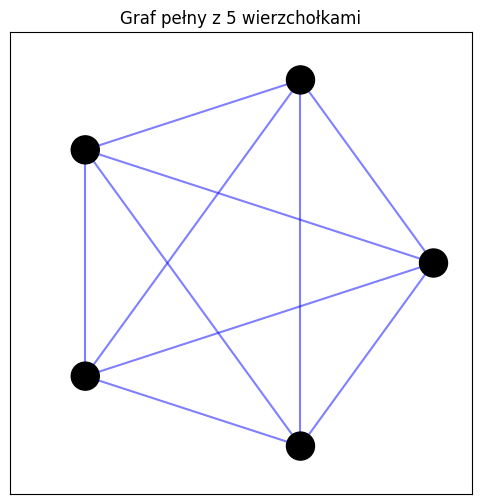

In [2]:
# zadanie 3 Napisz program wyświetlający graf pełny o parametrach:
# • liczba wierzchołków jest zadana parametrycznie (należy zapytać użytkownika, np. z poziomu konsoli),
# • wierzchołki są rozmieszczone na okręgu, w równych odstępach między kolejnymi wierzchołkami,
# • etykiety wierzchołkow są kolejnymi liczbami naturalnymi.
# Procedurę umieszczania wierzchołków na okręgu przygotuj samodzielnie. Wykorzystaj odpowiednie funkcje
# trygonometryczne.
# Wejście: liczba wierzchołków.
# Wyjście: wyświetlony graf.
print("ZADANIE 3")

def rys_graf_pelnego(n):
    R = 5 # promien
    angles= np.linspace(0, 2 * np.pi, n, endpoint=False)
    pkt = [(R * np.cos(angle), R * np.sin(angle)) for angle in angles]
    fig, ax = plt.subplots(figsize=(6, 6))

    # krawedzie
    for i in range(n):
        for j in range(i + 1, n):
            x_values = [pkt[i][0], pkt[j][0]]
            y_values = [pkt[i][1], pkt[j][1]]
            ax.plot(x_values, y_values, 'blue', alpha=0.5)

    #wierzcholki i etykiety
    for index, (x, y) in enumerate(pkt):
        ax.plot(x, y, 'ro', markersize=8)
        ax.text(x, y, str(index + 1), fontsize=12, ha='center', va='center', color='black',
                bbox=dict(facecolor='black', edgecolor='black', boxstyle='circle'))
    ax.set_xlim(-R - 1, R + 1)
    ax.set_ylim(-R - 1, R + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    ax.set_title(f'Graf pełny z {n} wierzchołkami')
    plt.show()

n = int(input("Podaj liczbę wierzchołków: "))
rys_graf_pelnego(n)


ZADANIE 4


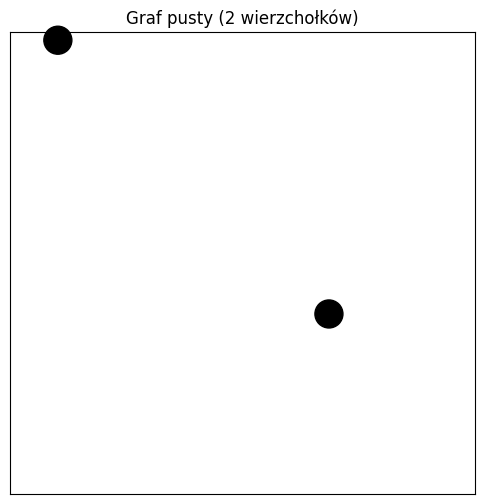

In [9]:
# zadanie 4.Napisz program wyświetlający graf pusty o parametrycznie zadanej liczbie wierzchołków (podawana przez
# użytkownika). Wierzchołki są generowane na losowej pozycji na płaszczyźnie Oxy. Losowej, czyli losowanej z
# rozkładów jednostajnych dla osi Ox i Oy na pewnych ustalonych przedziałach (podanych przez użytkownika).
# Wyświetl uzyskany graf.
# Wejście: liczba wierzchołków, przedział na osi Ox, przedział na osi Oy.
# Wyjście: wyświetlony graf.
print("ZADANIE 4")

import numpy as np
import matplotlib.pyplot as plt


def rys_graf_pusty(n, x_min, x_max, y_min, y_max):
    x_coords = np.random.uniform(x_min, x_max, n)
    y_coords = np.random.uniform(y_min, y_max, n)
    fig, ax = plt.subplots(figsize=(6, 6))

    # wierzchołki
    for i in range(n):
        ax.plot(x_coords[i], y_coords[i],'ro', markersize=8)
        ax.text(x_coords[i], y_coords[i], str(i + 1), fontsize=12, ha='center', va='center', color='black',
                bbox=dict(facecolor='black', edgecolor='black', boxstyle='circle'))

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Graf pusty ({n} wierzchołków)')
    plt.show()

n = int(input("Podaj liczbę wierzchołków: "))
x_min, x_max = map(float, input("Podaj przedział dla osi Ox (np. -5 5): ").split())
y_min, y_max = map(float, input("Podaj przedział dla osi Oy (np. -5 5): ").split())

rys_graf_pusty(n, x_min, x_max, y_min, y_max)

ZADANIE 5


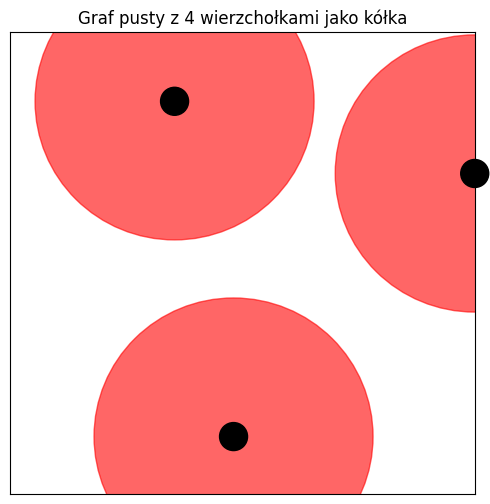

In [11]:
# zadanie 5. Zmodyfikuj poprzedni program tak, aby wierzchołki stały się środkiem kół o jednakowym promieniu (zada-
# nym przez użytkownika). Wierzchołki dodawaj do okręgu pojedynczo, w następujący sposób.
# 1. Losuj pozycję (x, y) nowego wierzchołka.
# 2. Wyświetl wierzchołek (dodaj do wyświetlanego grafu odpowiednie koło).
# 3. Sprawdź, czy koło o środku (x, y) zachodzi na dowolne inne koło.
# 4. Jeśli zachodzi, to: odrzuć wierzchołek, usuń wyświetlone wcześniej koło (możesz przerysować cały graf)
# i wróć do 1. Przerwij procedurę dodawania wierzchołków, jeśli nie udało się dodać nowego w ciągu 10
# iteracji.
# Wejście: liczba wierzchołków, przedział na osi Ox, przedział na osi Oy, promień koła.
# Wyjście: graf wyświetlany wierzchołek po wierzchołku (np. kolejny wierzchołek po naciśnięciu spacji).
# Uwaga: jeśli jest mowa o modyfikacji poprzedniego/wcześniejszego programu, to nadal należy zachować wersję z
# poprzedniego/wcześniejszego zadania.
print("ZADANIE 5")
import keyboard
def czy_nachodzi(new_x, new_y, vertices, radius):
    for (x, y) in vertices:
        distance = np.sqrt((new_x - x) ** 2 + (new_y - y) ** 2)
        if distance < 2 * radius:
            return True
    return False
def rys_graf_modyfikacja(n, x_min, x_max, y_min, y_max, radius):
    vertices = []
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Graf pusty z {n} wierzchołkami jako kółka')

    for i in range(n):
        attempts = 0

        while attempts < 10:
            new_x = np.random.uniform(x_min, x_max)
            new_y = np.random.uniform(y_min, y_max)

            if not czy_nachodzi(new_x, new_y, vertices, radius):
                vertices.append((new_x, new_y))

                circle = plt.Circle((new_x, new_y), radius, color='red', alpha=0.6)
                ax.add_patch(circle)

                ax.text(new_x, new_y, str(i + 1), fontsize=12, ha='center', va='center', color='black',
                        bbox=dict(facecolor='black', edgecolor='black', boxstyle='circle'))

                plt.draw()
                break

            attempts += 1

        input(f"Naciśnij ENTER, aby dodać kolejny wierzchołek ({i + 1}/{n})")

    plt.show()

n = int(input("Podaj liczbę wierzchołków: "))
x_min, x_max = map(float, input("Podaj przedział dla osi Ox (np. -5 5): ").split())
y_min, y_max = map(float, input("Podaj przedział dla osi Oy (np. -5 5): ").split())
radius = float(input("Podaj promień koła: "))

rys_graf_modyfikacja(n, x_min, x_max, y_min, y_max, radius)